<a href="https://colab.research.google.com/github/useanynoms-commits/IDRA/blob/main/Assignment_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

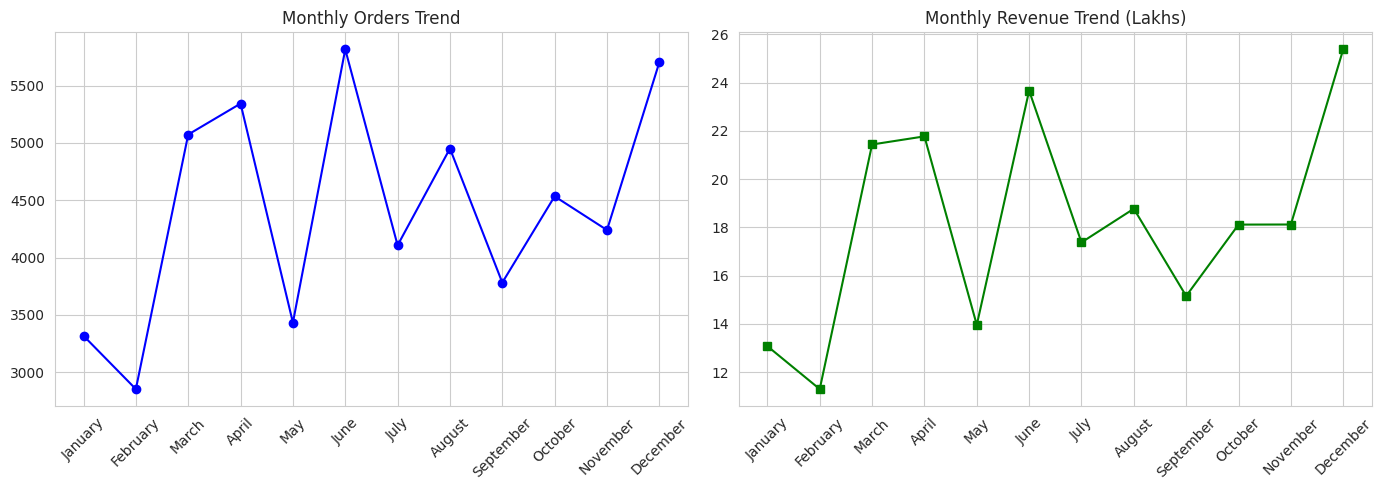

In [2]:
"""
Food Delivery Business Performance Dashboard
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Day14_Food_Delivery_Visualization_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Monthly trends
monthly = df.groupby('Month').agg({'Orders':'sum', 'Revenue':'sum'}).reset_index()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(monthly['Month'], monthly['Orders'], marker='o', color='blue')
axes[0].set_title('Monthly Orders Trend')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(monthly['Month'], monthly['Revenue']/100000, marker='s', color='green')
axes[1].set_title('Monthly Revenue Trend (Lakhs)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

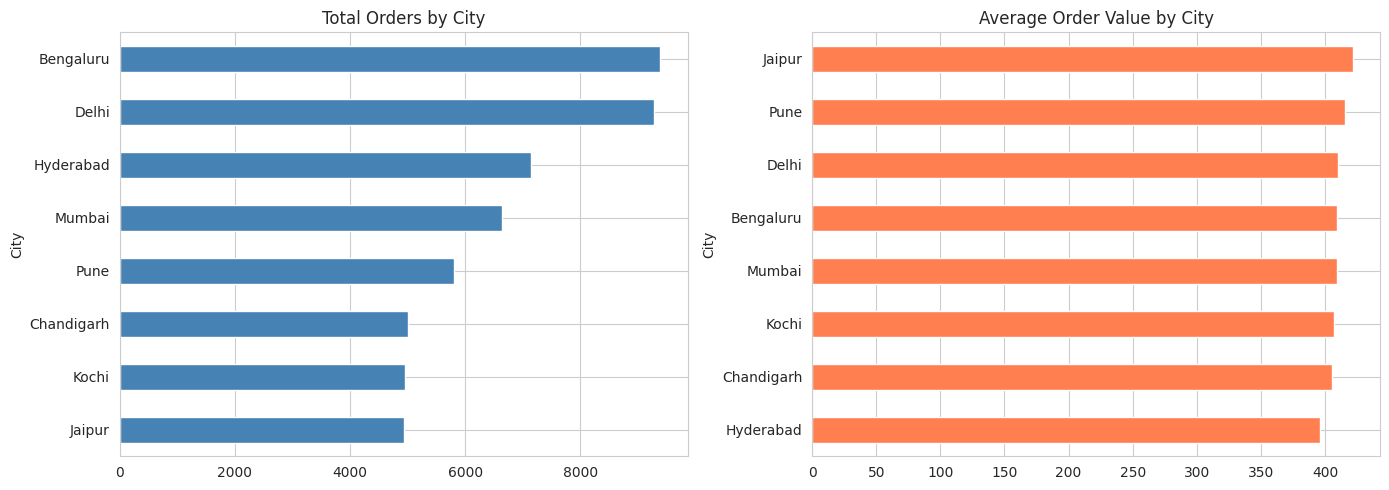

In [3]:
# 2. City performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_orders = df.groupby('City')['Orders'].sum().sort_values()
city_orders.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Orders by City')
city_aov = df.groupby('City')['Average_Order_Value'].mean().sort_values()
city_aov.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average Order Value by City')
plt.tight_layout()
plt.show()

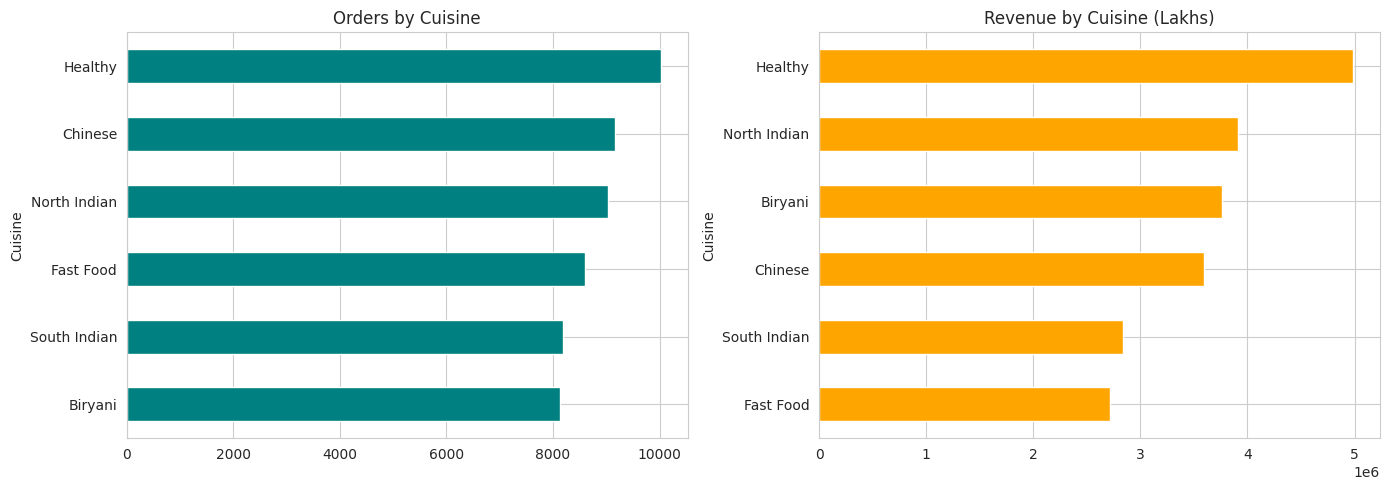

In [4]:
# 3. Cuisine analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cuisine_orders = df.groupby('Cuisine')['Orders'].sum().sort_values()
cuisine_orders.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Orders by Cuisine')
cuisine_revenue = df.groupby('Cuisine')['Revenue'].sum().sort_values()
cuisine_revenue.plot(kind='barh', ax=axes[1], color='orange')
axes[1].set_title('Revenue by Cuisine (Lakhs)')
plt.tight_layout()
plt.show()


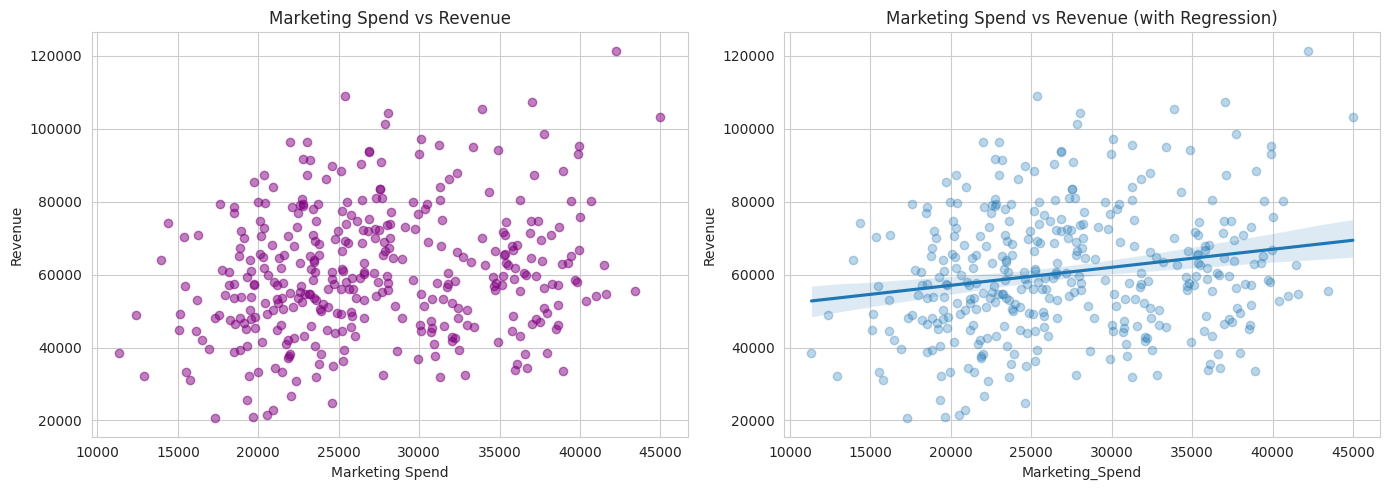

In [5]:
# 4. Marketing spend vs revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['Marketing_Spend'], df['Revenue'], alpha=0.5, color='purple')
axes[0].set_title('Marketing Spend vs Revenue')
axes[0].set_xlabel('Marketing Spend')
axes[0].set_ylabel('Revenue')
sns.regplot(data=df, x='Marketing_Spend', y='Revenue', ax=axes[1], scatter_kws={'alpha':0.3})
axes[1].set_title('Marketing Spend vs Revenue (with Regression)')
plt.tight_layout()
plt.show()

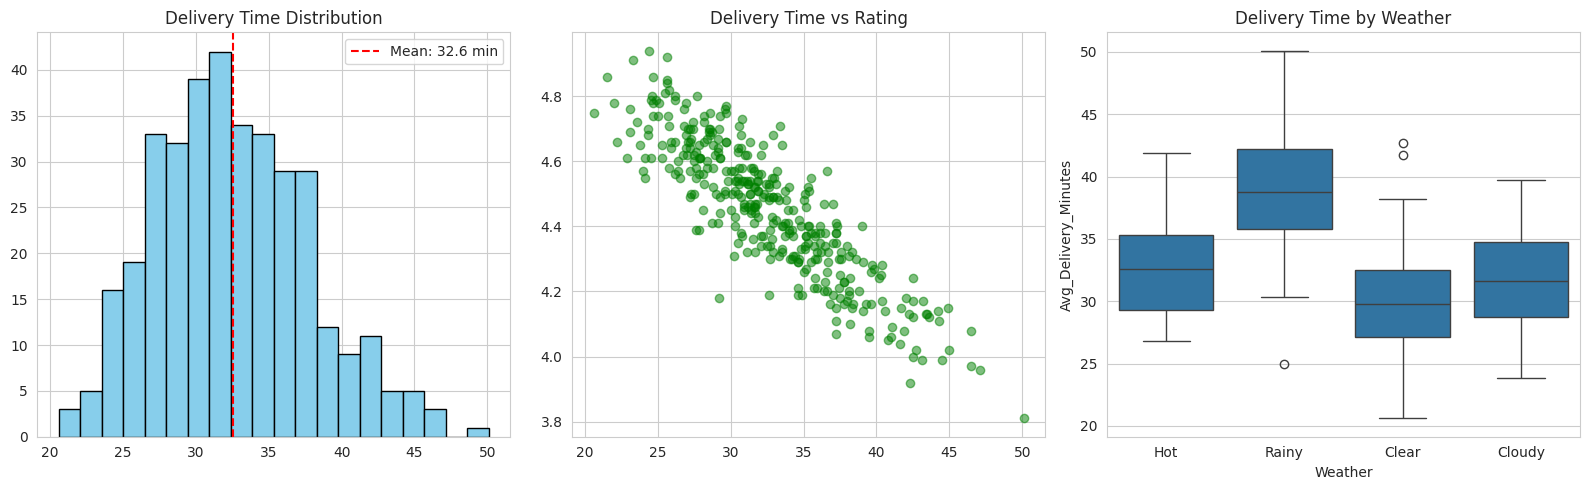

In [6]:
# 5. Delivery time and satisfaction
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(df['Avg_Delivery_Minutes'], bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(df['Avg_Delivery_Minutes'].mean(), color='red', linestyle='dashed', label=f'Mean: {df["Avg_Delivery_Minutes"].mean():.1f} min')
axes[0].set_title('Delivery Time Distribution')
axes[0].legend()
axes[1].scatter(df['Avg_Delivery_Minutes'], df['Customer_Rating'], alpha=0.5, color='green')
axes[1].set_title('Delivery Time vs Rating')
sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes', ax=axes[2])
axes[2].set_title('Delivery Time by Weather')
plt.tight_layout()
plt.show()

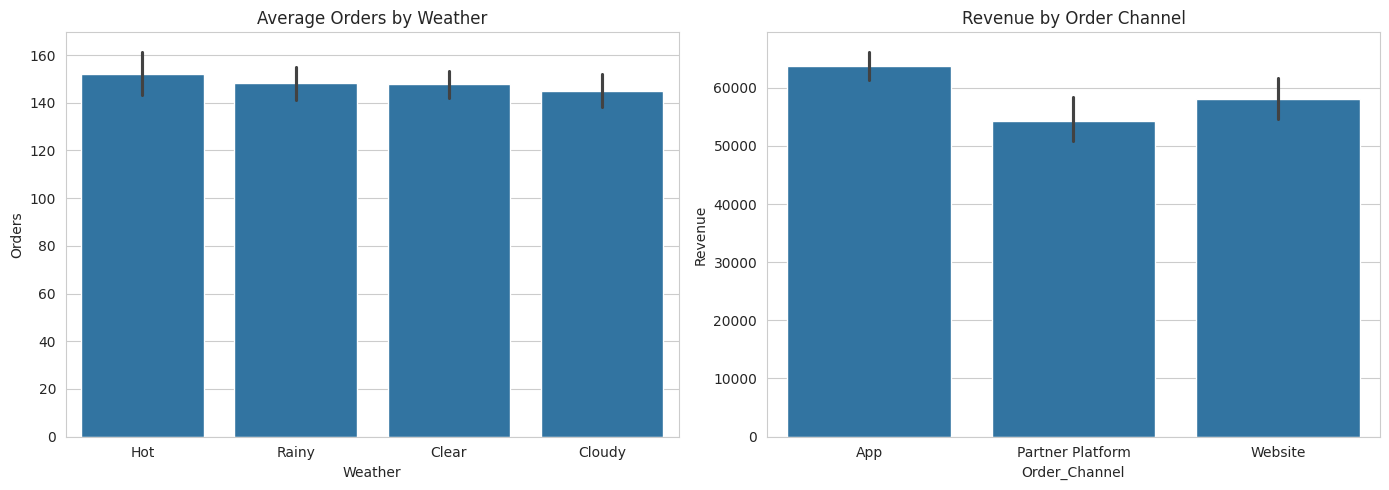

In [7]:
# 6. Weather and channel impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Weather', y='Orders', ax=axes[0])
axes[0].set_title('Average Orders by Weather')
sns.barplot(data=df, x='Order_Channel', y='Revenue', ax=axes[1])
axes[1].set_title('Revenue by Order Channel')
plt.tight_layout()
plt.show()

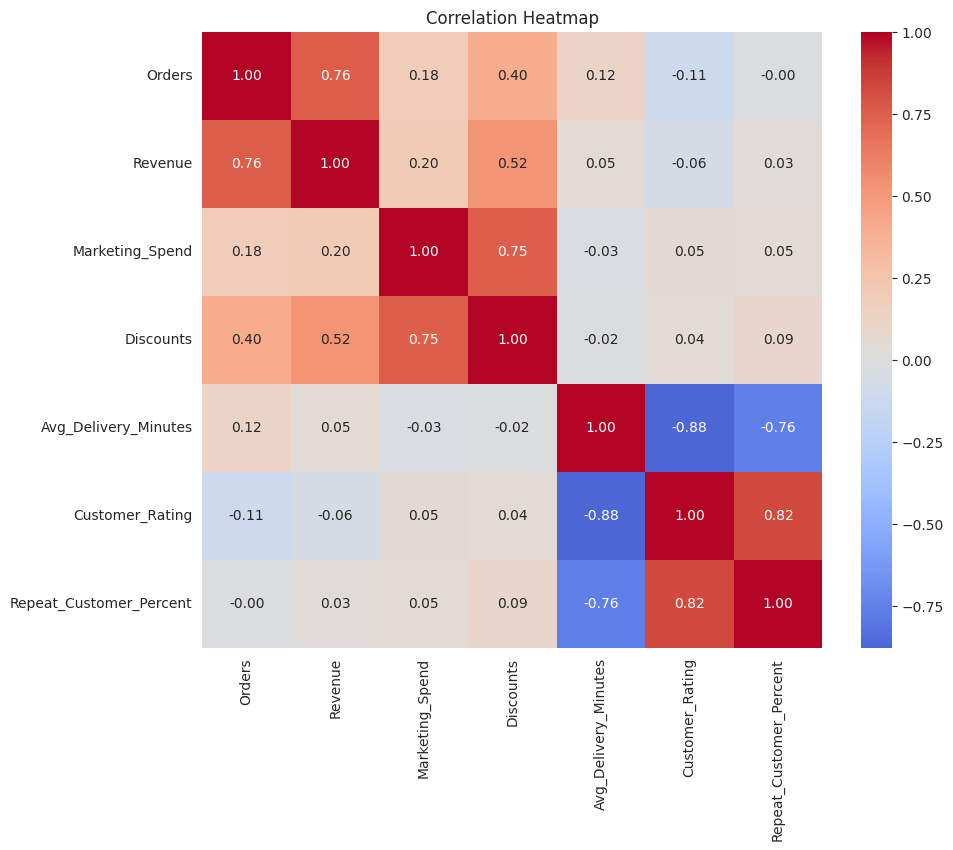

In [8]:
# 7. Correlation heatmap
numeric_cols = ['Orders', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

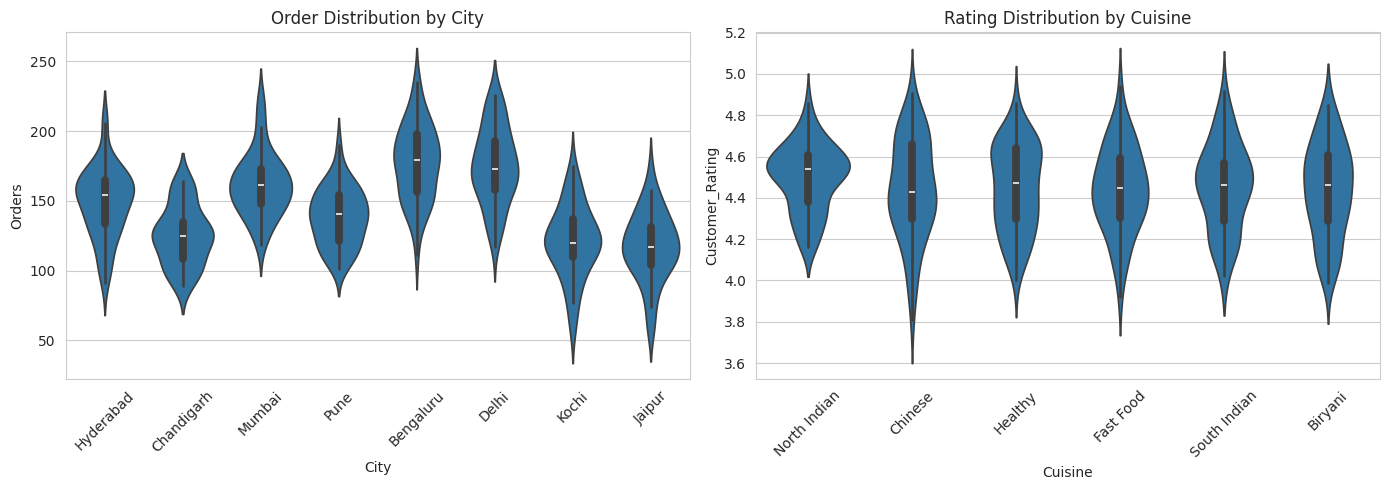

In [9]:
# 8. Violin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x='City', y='Orders', ax=axes[0])
axes[0].set_title('Order Distribution by City')
axes[0].tick_params(axis='x', rotation=45)
sns.violinplot(data=df, x='Cuisine', y='Customer_Rating', ax=axes[1])
axes[1].set_title('Rating Distribution by Cuisine')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

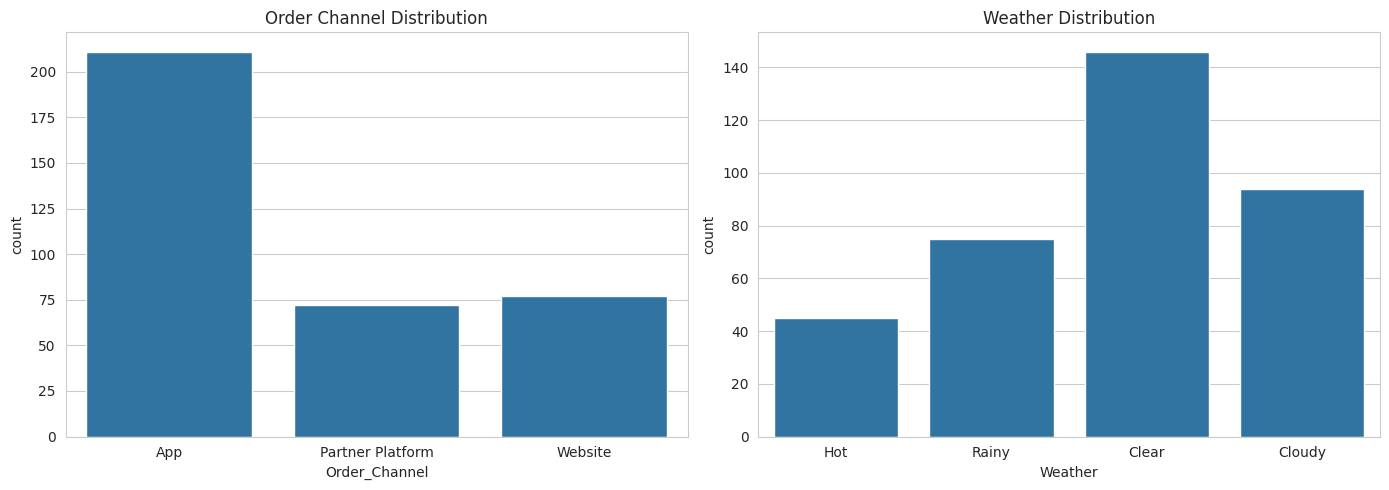

In [10]:
# 9. Count plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Order_Channel', ax=axes[0])
axes[0].set_title('Order Channel Distribution')
sns.countplot(data=df, x='Weather', ax=axes[1])
axes[1].set_title('Weather Distribution')
plt.tight_layout()
plt.show()

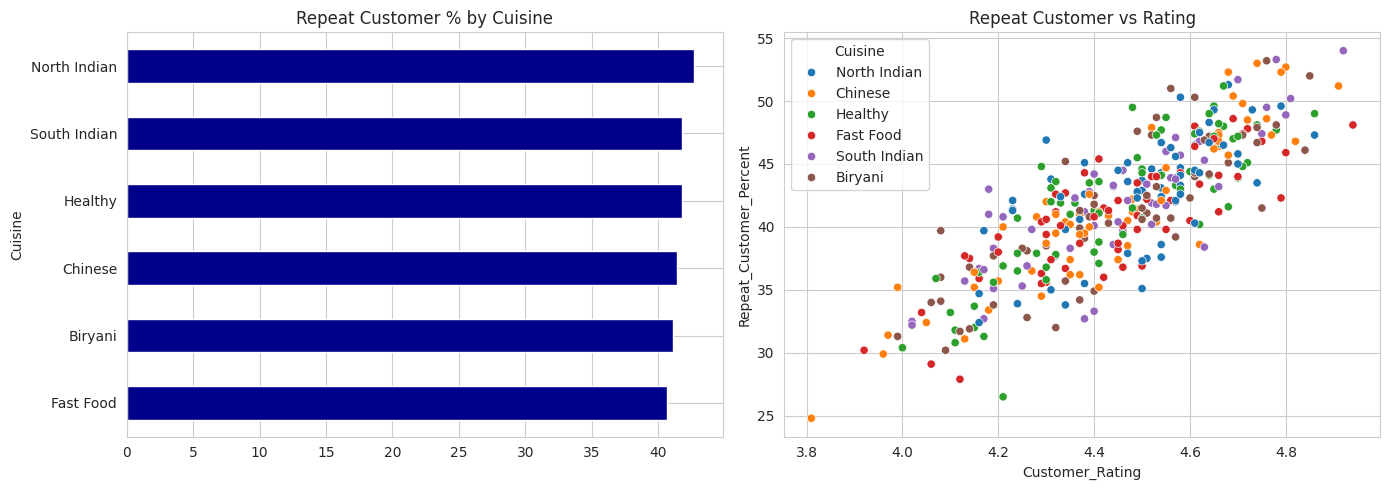

In [11]:
# 10. Repeat customer analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cuisine_repeat = df.groupby('Cuisine')['Repeat_Customer_Percent'].mean().sort_values()
cuisine_repeat.plot(kind='barh', ax=axes[0], color='darkblue')
axes[0].set_title('Repeat Customer % by Cuisine')
sns.scatterplot(data=df, x='Customer_Rating', y='Repeat_Customer_Percent', hue='Cuisine', ax=axes[1])
axes[1].set_title('Repeat Customer vs Rating')
plt.tight_layout()
plt.show()

In [12]:
# Summary
print(f"""
1. Top City by Orders: {df.groupby('City')['Orders'].sum().idxmax()}
2. Top City by Order Value: {df.groupby('City')['Average_Order_Value'].mean().idxmax()}
3. Best Cuisine by Orders: {df.groupby('Cuisine')['Orders'].sum().idxmax()}
4. Best Cuisine by Rating: {df.groupby('Cuisine')['Customer_Rating'].mean().idxmax()}
5. Marketing-Revenue Correlation: {df['Marketing_Spend'].corr(df['Revenue']):.3f}
6. Delivery-Rating Correlation: {df['Avg_Delivery_Minutes'].corr(df['Customer_Rating']):.3f}
7. Weather with Highest Ratings: {df.groupby('Weather')['Customer_Rating'].mean().idxmax()}
8. Most Used Channel: {df['Order_Channel'].mode()[0]}
9. Best Month for Orders: {monthly.loc[monthly['Orders'].idxmax(), 'Month']}
10. Best Month for Revenue: {monthly.loc[monthly['Revenue'].idxmax(), 'Month']}
11. Repeat-Rating Correlation: {df['Customer_Rating'].corr(df['Repeat_Customer_Percent']):.3f}
12. Average Delivery Time: {df['Avg_Delivery_Minutes'].mean():.1f} minutes
""")


1. Top City by Orders: Bengaluru
2. Top City by Order Value: Jaipur
3. Best Cuisine by Orders: Healthy
4. Best Cuisine by Rating: North Indian
5. Marketing-Revenue Correlation: 0.198
6. Delivery-Rating Correlation: -0.876
7. Weather with Highest Ratings: Clear
8. Most Used Channel: App
9. Best Month for Orders: June
10. Best Month for Revenue: December
11. Repeat-Rating Correlation: 0.824
12. Average Delivery Time: 32.6 minutes

